# 季节性分析

本笔记本分析四季销量变化、商品类别与季节关系、季节性颜色偏好及季节对消费金额的影响。
- 四季销量变化趋势
- 季节与商品类别的关系
- 季节性颜色偏好
- 季节对消费金额的影响

## 分析目标
揭示季节性消费规律，优化促销和产品策略。

## 1. 导入所需库和数据

In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')

# 读取数据
df = pd.read_csv('shopping_behavior_updated.csv')
print(f"数据形状: {df.shape}")
print(f"列名: {list(df.columns)}")
df.head()

数据形状: (3900, 18)
列名: ['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## 2. 四季销量变化趋势

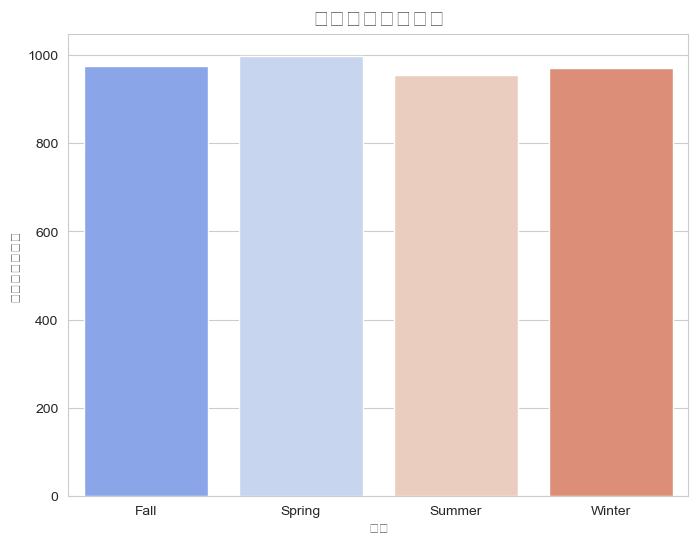

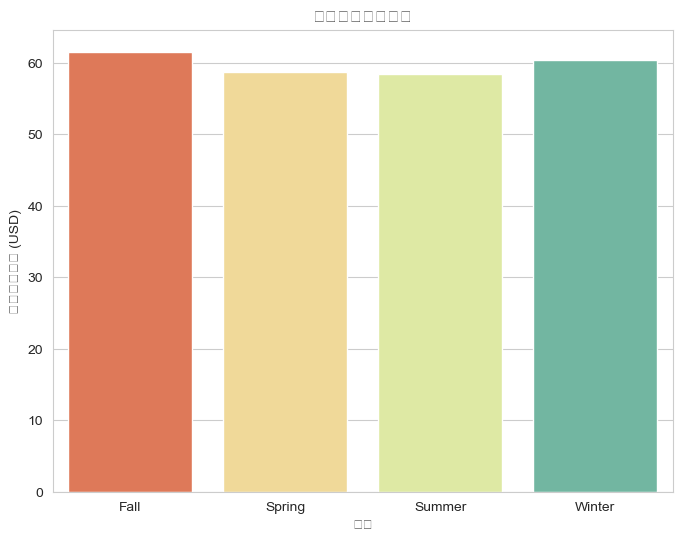

In [2]:
# 四季销量变化趋势
season_counts = df['Season'].value_counts().sort_index()
plt.figure(figsize=(8,6))
sns.barplot(x=season_counts.index, y=season_counts.values, palette='coolwarm')
plt.title('四季销量变化趋势', fontsize=16)
plt.xlabel('季节')
plt.ylabel('销量（客户数）')
plt.show()

# 按季节统计平均消费金额
season_avg = df.groupby('Season')['Purchase Amount (USD)'].mean().round(2)
plt.figure(figsize=(8,6))
sns.barplot(x=season_avg.index, y=season_avg.values, palette='Spectral')
plt.title('四季平均消费金额')
plt.xlabel('季节')
plt.ylabel('平均消费金额 (USD)')
plt.show()

## 3. 季节与商品类别的关系

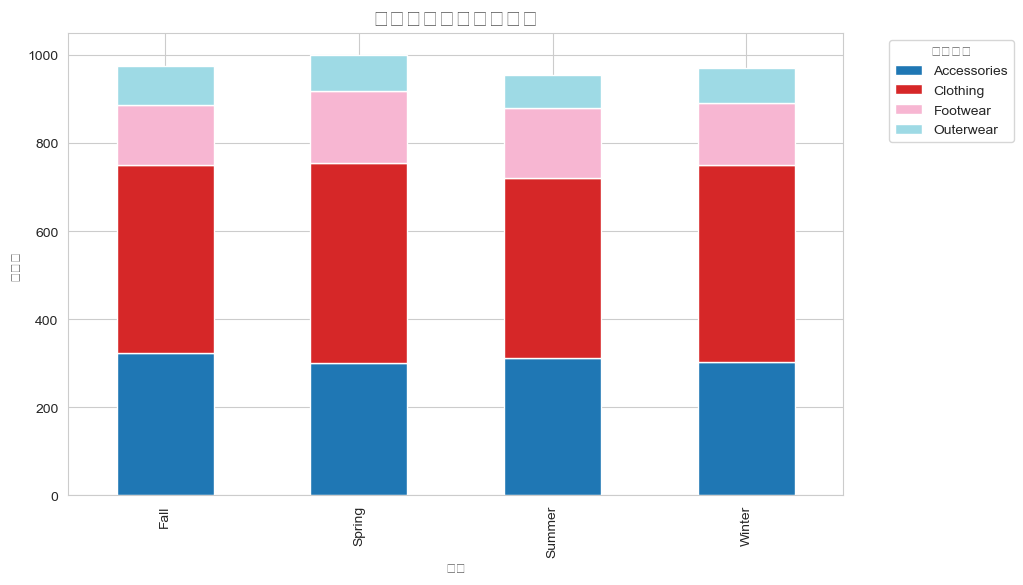

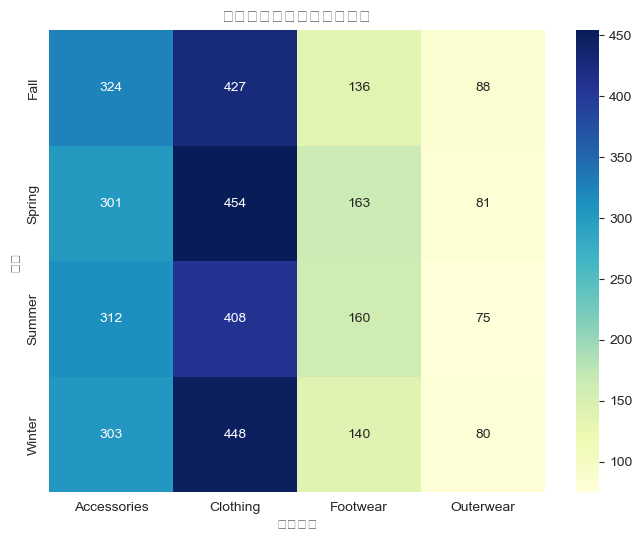

In [3]:
# 季节与商品类别的关系
season_category = pd.crosstab(df['Season'], df['Category'])
season_category.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')
plt.title('季节与商品类别的关系', fontsize=16)
plt.xlabel('季节')
plt.ylabel('客户数')
plt.legend(title='商品类别', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 热力图展示
plt.figure(figsize=(8,6))
sns.heatmap(season_category, annot=True, fmt='d', cmap='YlGnBu')
plt.title('季节与商品类别购买热力图')
plt.xlabel('商品类别')
plt.ylabel('季节')
plt.show()

## 4. 季节性颜色偏好

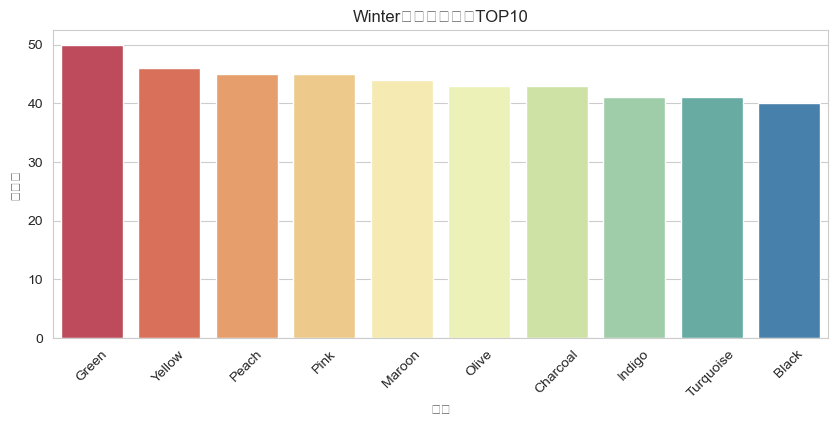

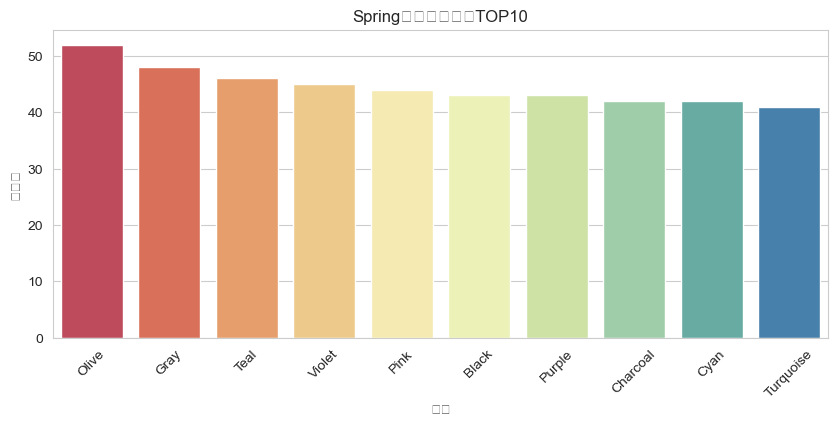

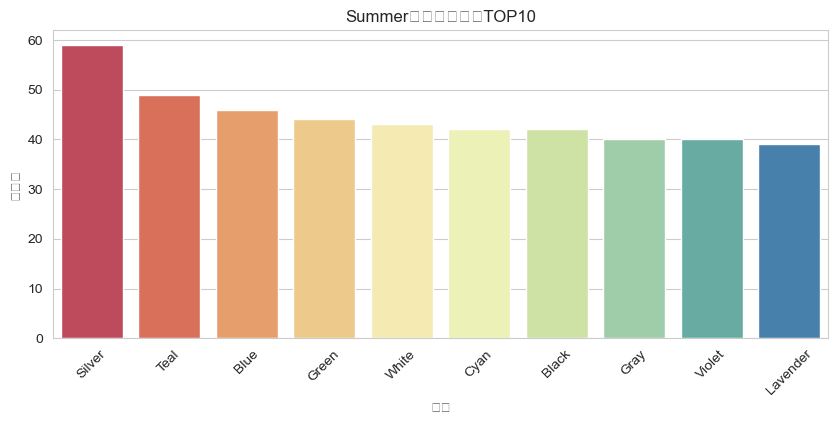

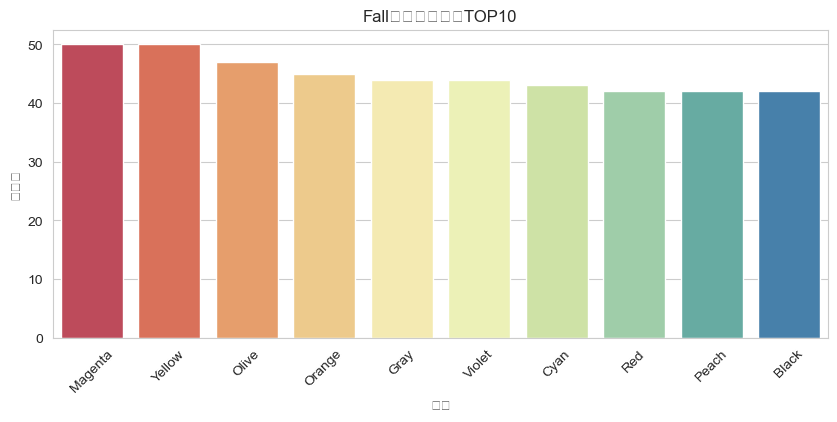

In [4]:
# 季节性颜色偏好
season_color = pd.crosstab(df['Season'], df['Color'])
season_color_pct = season_color.div(season_color.sum(axis=1), axis=0) * 100

# 选取每季前10热门颜色
for season in df['Season'].unique():
    top_colors = df[df['Season'] == season]['Color'].value_counts().head(10)
    plt.figure(figsize=(10,4))
    sns.barplot(x=top_colors.index, y=top_colors.values, palette='Spectral')
    plt.title(f'{season}季节热门颜色TOP10')
    plt.xlabel('颜色')
    plt.ylabel('客户数')
    plt.xticks(rotation=45)
    plt.show()

## 5. 季节对消费金额的影响

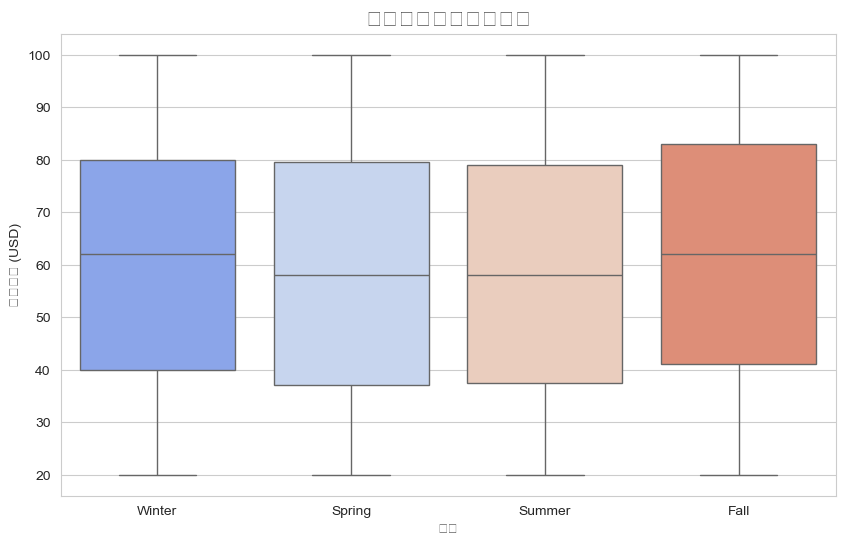

各季节消费金额统计：
         mean  median    std
Season                      
Fall    61.56    62.0  23.75
Spring  58.74    58.0  23.94
Summer  58.41    58.0  23.47
Winter  60.36    62.0  23.48


In [5]:
# 季节对消费金额的影响
plt.figure(figsize=(10,6))
sns.boxplot(x='Season', y='Purchase Amount (USD)', data=df, palette='coolwarm')
plt.title('季节对消费金额的影响', fontsize=16)
plt.xlabel('季节')
plt.ylabel('消费金额 (USD)')
plt.show()

# 按季节统计消费金额均值和中位数
season_stats = df.groupby('Season')['Purchase Amount (USD)'].agg(['mean','median','std']).round(2)
print("各季节消费金额统计：")
print(season_stats)

## 6. 主要发现与结论

- 各季节销量分布有明显差异，部分季节消费金额更高。
- 商品类别在不同季节表现不同，部分类别季节性强。
- 季节性颜色偏好明显，热门颜色随季节变化。
- 季节对消费金额有一定影响，需结合促销和产品策略优化。

*建议结合季节性规律，制定差异化营销和产品策略，提升客户体验和销售业绩。*